In [2]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.shape

(891, 15)

In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
freq = df['class'].value_counts()

In [10]:
print(freq)

class
Third     491
First     216
Second    184
Name: count, dtype: int64


In [11]:
relative = df['class'].value_counts(normalize=True)*100
print(relative)

class
Third     55.106622
First     24.242424
Second    20.650954
Name: proportion, dtype: float64


In [12]:
cumalative = freq.cumsum()
print(cumalative)

class
Third     491
First     707
Second    891
Name: count, dtype: int64


In [13]:
freq_table = pd.DataFrame({
    'Absolute Frequency':freq,
    'Relative Frequency (%)':relative,
    'Cumulative Frequency':cumalative
})
freq_table

,Absolute Frequency,Relative Frequency (%),Cumulative Frequency
class,,,
Third,491,55.106622,491
First,216,24.242424,707
Second,184,20.650954,891


In [14]:
contingency = pd.crosstab(df['class'], df['sex'])
contingency

sex,female,male
class,,
First,94,122
Second,76,108
Third,144,347


In [15]:
joint_probab = contingency / len(df)
joint_probab

sex,female,male
class,,
First,0.105499,0.136925
Second,0.085297,0.121212
Third,0.161616,0.389450


In [16]:
gender_probab = df['sex'].value_counts(normalize=True)
gender_probab

sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [17]:
survival_probab = df['survived'].value_counts(normalize=True)
survival_probab

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [18]:
conditional = contingency.div(contingency.sum(axis=1), axis=0)

print(conditional)

sex       female      male
class                     
First   0.435185  0.564815
Second  0.413043  0.586957
Third   0.293279  0.706721


In [19]:
corr_df = df[['age','fare']]
corr_df

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
886,27.0,13.0000
887,19.0,30.0000
888,NaN,23.4500
889,26.0,30.0000


In [20]:
corr_df.isnull().sum()

age     177
fare      0
dtype: int64

In [21]:
corr_df.dropna(inplace=True)

In [22]:
corr_df.isnull().sum()

age     0
fare    0
dtype: int64

In [23]:
correlation = corr_df.corr()
correlation

,age,fare
age,1.000000,0.096067
fare,0.096067,1.000000


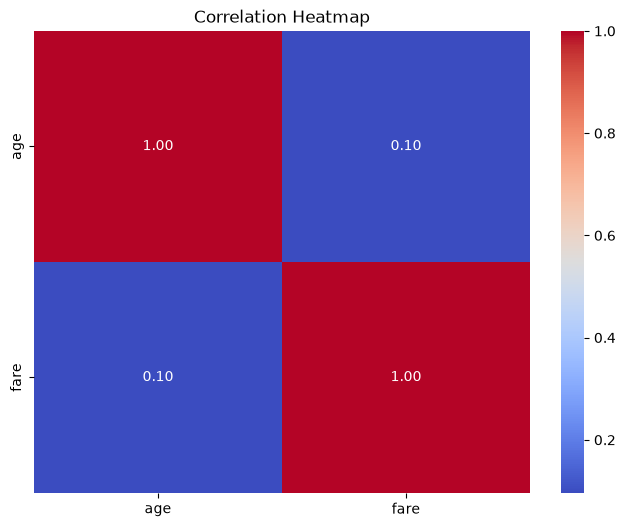

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

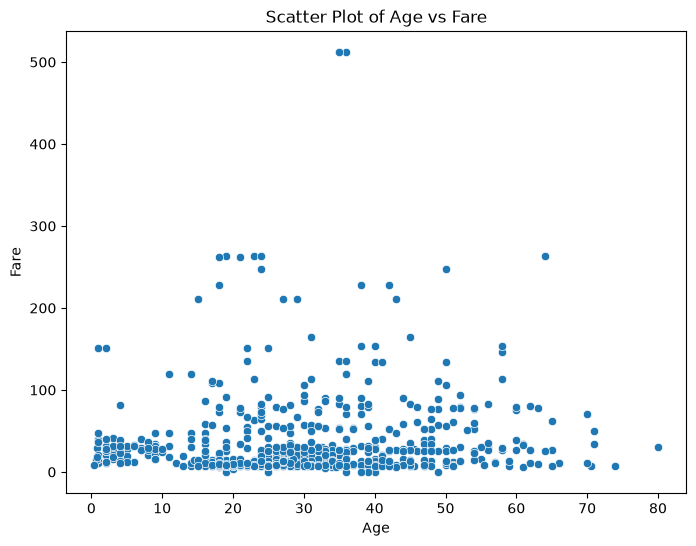

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=corr_df,x='age',y='fare')
plt.title('Scatter Plot of Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

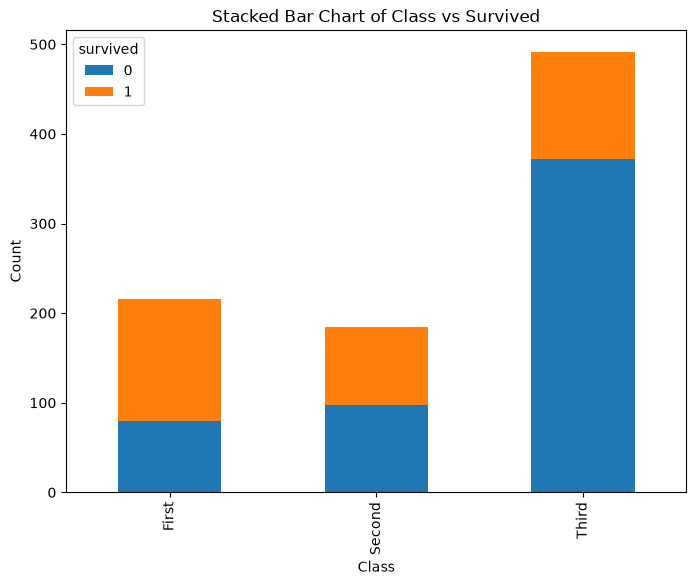

In [26]:
stacked = pd.crosstab(df['class'], df['survived'])
stacked.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title('Stacked Bar Chart of Class vs Survived')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [27]:
embarked = df['embarked'].value_counts()

print(embarked)

embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [28]:
prob_survived = df['survived'].mean()

print(prob_survived)

0.3838383838383838


In [29]:
print(df[['age','fare']].dropna().corr())

           age      fare
age   1.000000  0.096067
fare  0.096067  1.000000
